In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')

DATA_DIR   = '../backend/data/'
MODELS_DIR = '../backend/models/'
os.makedirs(MODELS_DIR, exist_ok=True)

print('✅ All imports successful — no extra installs needed!')

✅ All imports successful — no extra installs needed!


In [2]:
ratings = pd.read_csv(os.path.join(DATA_DIR, 'ratings.csv'))
movies  = pd.read_csv(os.path.join(DATA_DIR, 'movies.csv'))

print(f'Ratings : {ratings.shape}')
print(f'Movies  : {movies.shape}')
print(f'Users   : {ratings.user_id.nunique()}')
print(f'Rating scale: {ratings.rating.min()} – {ratings.rating.max()}')
ratings.head()

Ratings : (100836, 4)
Movies  : (9742, 7)
Users   : 610
Rating scale: 0.5 – 5.0


,user_id,movie_id,rating,rated_at
0,1,1,4.0,2000-07-30 18:45:03
1,1,3,4.0,2000-07-30 18:20:47
2,1,6,4.0,2000-07-30 18:37:04
3,1,47,5.0,2000-07-30 19:03:35
4,1,50,5.0,2000-07-30 18:48:51


## Build the User-Item Rating Matrix

In [3]:

rating_matrix = ratings.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
).fillna(0)

print(f'Rating Matrix shape: {rating_matrix.shape}')
print(f'  → {rating_matrix.shape[0]} users × {rating_matrix.shape[1]} movies')

user_ids  = rating_matrix.index.tolist()
movie_ids = rating_matrix.columns.tolist()

total_cells  = rating_matrix.shape[0] * rating_matrix.shape[1]
filled_cells = (rating_matrix != 0).sum().sum()
sparsity     = 1 - filled_cells / total_cells
print(f'\nSparsity: {sparsity:.2%} of ratings are missing')
print('→ This is why we need SVD to fill in the gaps')

Rating Matrix shape: (610, 9724)
  → 610 users × 9724 movies

Sparsity: 98.30% of ratings are missing
→ This is why we need SVD to fill in the gaps


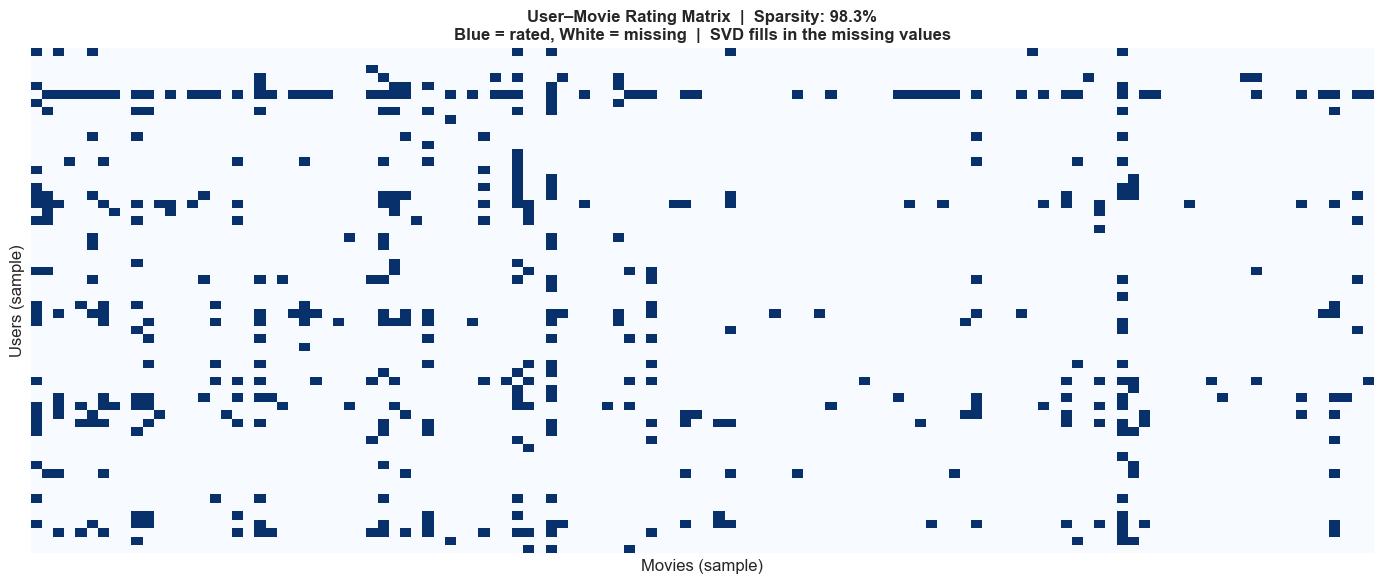

In [4]:

sample = rating_matrix.iloc[:60, :120]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    (sample != 0).astype(int),
    cmap='Blues', cbar=False, ax=ax,
    xticklabels=False, yticklabels=False
)
ax.set_title(
    f'User–Movie Rating Matrix  |  Sparsity: {sparsity:.1%}\n'
    f'Blue = rated, White = missing  |  SVD fills in the missing values',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Movies (sample)')
ax.set_ylabel('Users (sample)')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'collab_sparsity.png'), bbox_inches='tight')
plt.show()

## Mean-Center the Matrix


In [5]:
matrix_values = rating_matrix.values.astype(float)

user_ratings_mean = np.true_divide(
    matrix_values.sum(axis=1),
    (matrix_values != 0).sum(axis=1)
)


matrix_demeaned = matrix_values.copy()
for i in range(matrix_demeaned.shape[0]):
    rated_mask = matrix_demeaned[i] != 0
    matrix_demeaned[i][rated_mask] -= user_ratings_mean[i]

print(f'Mean-centering done!')
print(f'Global mean rating: {user_ratings_mean.mean():.2f}')
print(f'Sample user means (first 5): {user_ratings_mean[:5].round(2)}')

Mean-centering done!
Global mean rating: 3.66
Sample user means (first 5): [4.37 3.95 2.44 3.56 3.64]


## SVD Decomposition

In [6]:

sparse_matrix = csr_matrix(matrix_demeaned)
K = 50

print(f'Running SVD with k={K} latent factors...')
U, sigma, Vt = svds(sparse_matrix, k=K)


U     = U[:, ::-1]
sigma = sigma[::-1]
Vt    = Vt[::-1, :]

print(f'\n✅ SVD complete!')
print(f'U  shape: {U.shape}    (users × latent factors)')
print(f'Σ  shape: {sigma.shape}          (singular values)')
print(f'Vᵀ shape: {Vt.shape}  (latent factors × movies)')

Running SVD with k=50 latent factors...

✅ SVD complete!
U  shape: (610, 50)    (users × latent factors)
Σ  shape: (50,)          (singular values)
Vᵀ shape: (50, 9724)  (latent factors × movies)


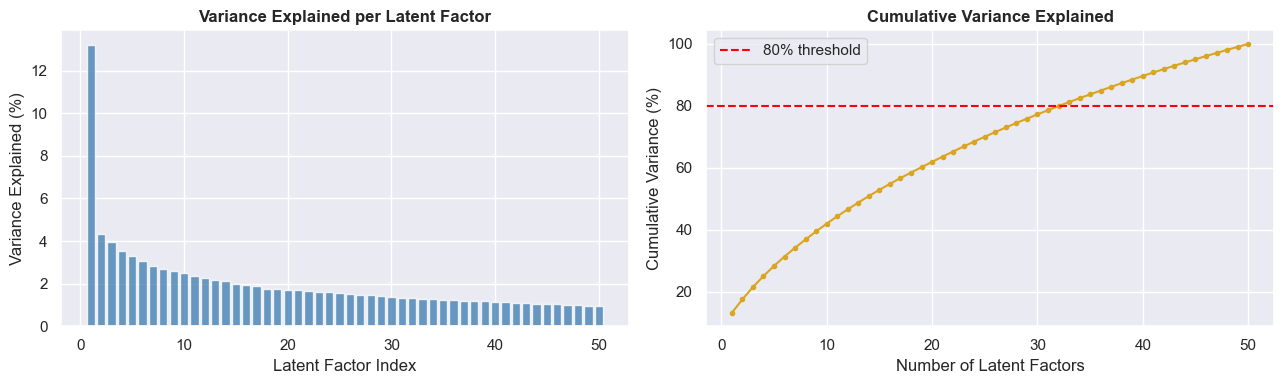

Factors needed for 80% variance: 33


In [7]:

explained   = (sigma ** 2) / (sigma ** 2).sum()
cumulative  = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, K+1), explained * 100, color='steelblue', alpha=0.8)
axes[0].set_title('Variance Explained per Latent Factor', fontweight='bold')
axes[0].set_xlabel('Latent Factor Index')
axes[0].set_ylabel('Variance Explained (%)')

axes[1].plot(range(1, K+1), cumulative * 100, marker='o', markersize=3, color='goldenrod')
axes[1].axhline(80, color='red', linestyle='--', label='80% threshold')
axes[1].set_title('Cumulative Variance Explained', fontweight='bold')
axes[1].set_xlabel('Number of Latent Factors')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'collab_singular_values.png'), bbox_inches='tight')
plt.show()

k_for_80 = np.argmax(cumulative >= 0.80) + 1
print(f'Factors needed for 80% variance: {k_for_80}')

## Reconstruct Predicted Ratings

In [8]:

predicted_ratings = np.dot(np.dot(U, np.diag(sigma)), Vt)
predicted_ratings += user_ratings_mean.reshape(-1, 1)
predicted_ratings  = np.clip(predicted_ratings, 1, 5)

predicted_df = pd.DataFrame(
    predicted_ratings,
    index   = rating_matrix.index,
    columns = rating_matrix.columns
)

print(f'Predicted matrix shape: {predicted_df.shape}')
print(f'\nSample predictions for User 1 (first 5 movies):')
print(predicted_df.iloc[0, :5].round(2).to_string())

Predicted matrix shape: (610, 9724)

Sample predictions for User 1 (first 5 movies):
movie_id
1    4.31
2    4.30
3    4.41
4    4.37
5    4.34


## Evaluate the Model

In [9]:

actual_mask    = matrix_values != 0
actual_vals    = matrix_values[actual_mask]
predicted_vals = predicted_ratings[actual_mask]

rmse = np.sqrt(mean_squared_error(actual_vals, predicted_vals))
mae  = mean_absolute_error(actual_vals, predicted_vals)

print('=== Model Evaluation ===')
print(f'RMSE : {rmse:.4f}  (error in rating units)')
print(f'MAE  : {mae:.4f}  (avg absolute error)')
print(f'\nPredictions are off by ~{mae:.2f} stars on average')

=== Model Evaluation ===
RMSE : 0.6199  (error in rating units)
MAE  : 0.4002  (avg absolute error)

Predictions are off by ~0.40 stars on average


Testing different K values...
  k= 10 → RMSE: 0.8048 | MAE: 0.5907
  k= 20 → RMSE: 0.7447 | MAE: 0.5283
  k= 30 → RMSE: 0.6980 | MAE: 0.4766
  k= 50 → RMSE: 0.6199 | MAE: 0.4002
  k= 75 → RMSE: 0.5430 | MAE: 0.3299
  k=100 → RMSE: 0.4787 | MAE: 0.2745


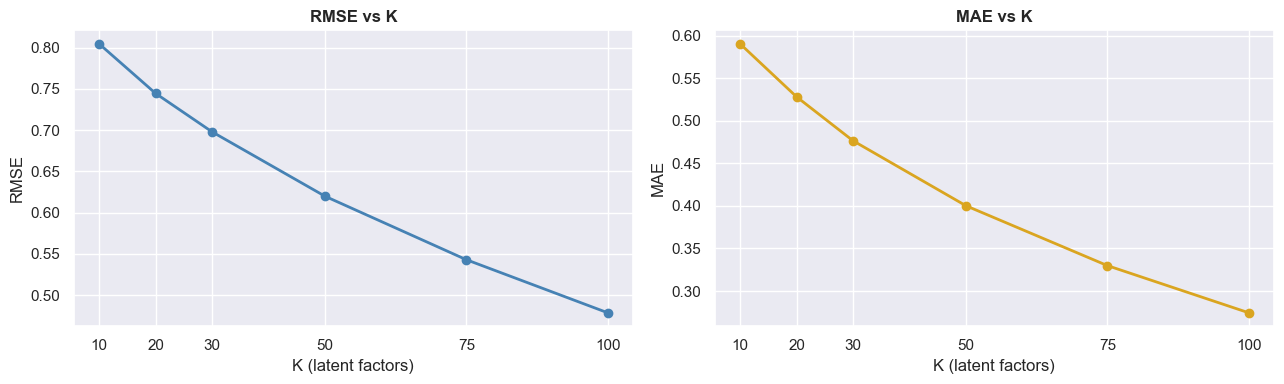


Best K by RMSE: 100


In [10]:

print('Testing different K values...')

k_values = [10, 20, 30, 50, 75, 100]
k_rmse, k_mae = [], []

for k in k_values:
    U_k, s_k, Vt_k = svds(sparse_matrix, k=k)
    pred_k = np.dot(np.dot(U_k, np.diag(s_k)), Vt_k)
    pred_k += user_ratings_mean.reshape(-1, 1)
    pred_k  = np.clip(pred_k, 1, 5)
    k_rmse.append(np.sqrt(mean_squared_error(actual_vals, pred_k[actual_mask])))
    k_mae.append(mean_absolute_error(actual_vals, pred_k[actual_mask]))
    print(f'  k={k:3d} → RMSE: {k_rmse[-1]:.4f} | MAE: {k_mae[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_values, k_rmse, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('RMSE vs K', fontweight='bold')
axes[0].set_xlabel('K (latent factors)')
axes[0].set_ylabel('RMSE')
axes[0].set_xticks(k_values)

axes[1].plot(k_values, k_mae, marker='o', color='goldenrod', linewidth=2)
axes[1].set_title('MAE vs K', fontweight='bold')
axes[1].set_xlabel('K (latent factors)')
axes[1].set_ylabel('MAE')
axes[1].set_xticks(k_values)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'collab_k_tuning.png'), bbox_inches='tight')
plt.show()

best_k = k_values[np.argmin(k_rmse)]
print(f'\nBest K by RMSE: {best_k}')

In [11]:

U_best, s_best, Vt_best = svds(sparse_matrix, k=best_k)
predicted_best = np.dot(np.dot(U_best, np.diag(s_best)), Vt_best)
predicted_best += user_ratings_mean.reshape(-1, 1)
predicted_best  = np.clip(predicted_best, 1, 5)

predicted_df = pd.DataFrame(
    predicted_best,
    index   = rating_matrix.index,
    columns = rating_matrix.columns
)

final_rmse = np.sqrt(mean_squared_error(actual_vals, predicted_best[actual_mask]))
final_mae  = mean_absolute_error(actual_vals, predicted_best[actual_mask])
print(f'Final RMSE : {final_rmse:.4f}')
print(f'Final MAE  : {final_mae:.4f}')

Final RMSE : 0.4787
Final MAE  : 0.2745


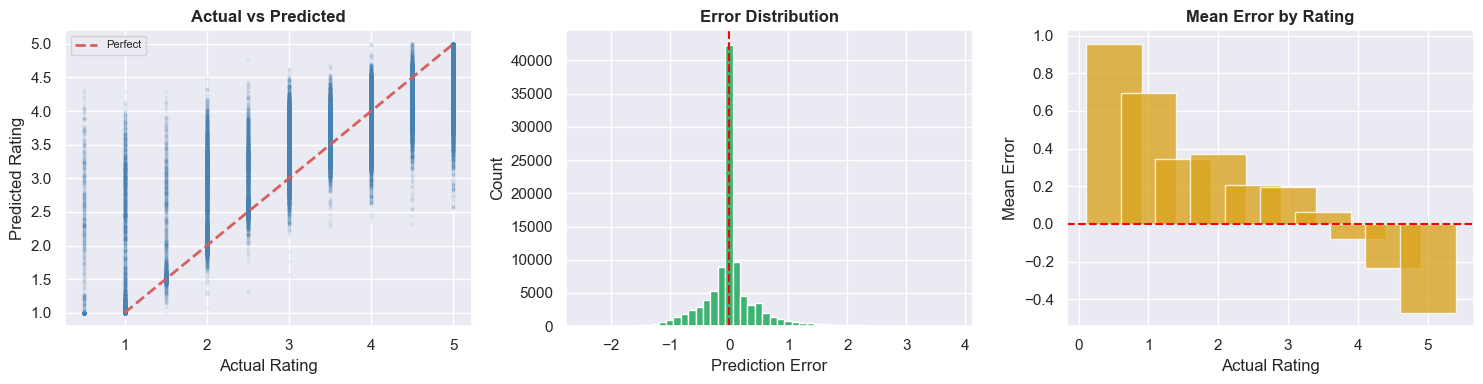

Mean error: 0.0226  (close to 0 = unbiased)


In [12]:

errors = predicted_best[actual_mask] - actual_vals

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(actual_vals, predicted_best[actual_mask], alpha=0.05, s=4, color='steelblue')
axes[0].plot([1, 5], [1, 5], 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual Rating')
axes[0].set_ylabel('Predicted Rating')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].hist(errors, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Prediction Error')
axes[1].set_ylabel('Count')
axes[1].set_title('Error Distribution', fontweight='bold')

error_df = pd.DataFrame({'actual': actual_vals, 'error': errors})
error_by_rating = error_df.groupby('actual')['error'].mean()
axes[2].bar(error_by_rating.index, error_by_rating.values, color='goldenrod', alpha=0.8)
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Actual Rating')
axes[2].set_ylabel('Mean Error')
axes[2].set_title('Mean Error by Rating', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'collab_error_analysis.png'), bbox_inches='tight')
plt.show()
print(f'Mean error: {errors.mean():.4f}  (close to 0 = unbiased)')

## Recommendation Functions

In [13]:
def get_unseen_movies(user_id):
   
    user_row   = rating_matrix.loc[user_id]
    return user_row[user_row == 0].index.tolist()


def recommend_for_user(user_id, n=10):
    
    if user_id not in predicted_df.index:
        return f'User {user_id} not found.'

    unseen_ids       = get_unseen_movies(user_id)
    user_preds       = predicted_df.loc[user_id, unseen_ids]
    top_ids          = user_preds.sort_values(ascending=False).head(n).index.tolist()
    top_scores       = user_preds.sort_values(ascending=False).head(n).values

    results = []
    for mid, score in zip(top_ids, top_scores):
        info = movies[movies['movie_id'] == mid]
        if len(info) > 0:
            r = info.iloc[0]
            results.append({
                'title_clean'      : r['title_clean'],
                'genres'           : r['genres'],
                'year'             : r['year'],
                'predicted_rating' : round(score, 3),
                'avg_rating'       : round(r['rating_mean'], 3),
                'num_ratings'      : int(r['rating_count'])
            })
    return pd.DataFrame(results).reset_index(drop=True)


def get_user_history(user_id, n=10):
    
    return ratings[ratings['user_id'] == user_id].merge(
        movies[['movie_id', 'title_clean', 'genres', 'year']], on='movie_id'
    ).sort_values('rating', ascending=False)[['title_clean', 'genres', 'year', 'rating']].head(n)


print('=== User 1 — Watch History ===')
display(get_user_history(1, 8))

print('\n=== Top 10 Recommendations for User 1 ===')
recommend_for_user(user_id=1, n=10)

=== User 1 — Watch History ===


,title_clean,genres,year,rating
3,Seven (a.k.a. Se7en),Mystery|Thriller,1995.0,5.0
4,"Usual Suspects, The",Crime|Mystery|Thriller,1995.0,5.0
6,Bottle Rocket,Adventure|Comedy|Crime|Romance,1996.0,5.0
13,Dumb & Dumber (Dumb and Dumber),Adventure|Comedy,1994.0,5.0
11,Billy Madison,Comedy,1995.0,5.0
10,Desperado,Action|Romance|Western,1995.0,5.0
9,Canadian Bacon,Comedy|War,1995.0,5.0
8,Rob Roy,Action|Drama|Romance|War,1995.0,5.0



=== Top 10 Recommendations for User 1 ===


,title_clean,genres,year,predicted_rating,avg_rating,num_ratings
0,"Departed, The",Crime|Drama|Thriller,2006.0,4.807,4.25,107
1,Ace Ventura: When Nature Calls,Comedy,1995.0,4.805,2.73,88
2,"Lord of the Rings: The Return of the King, The",Action|Adventure|Drama|Fantasy,2003.0,4.713,4.12,185
3,"Bridge on the River Kwai, The",Adventure|Drama|War,1957.0,4.699,4.12,45
4,Dead Poets Society,Drama,1989.0,4.690,3.96,86
5,Rain Man,Drama,1988.0,4.687,3.81,96
6,One Flew Over the Cuckoo's Nest,Drama,1975.0,4.671,4.20,133
7,"Crow, The",Action|Crime|Fantasy|Thriller,1994.0,4.664,3.61,64
8,Casablanca,Drama|Romance,1942.0,4.640,4.24,100
9,Eternal Sunshine of the Spotless Mind,Drama|Romance|Sci-Fi,2004.0,4.622,4.16,131


In [14]:
print('=== Recommendations for User 50 ===')
display(recommend_for_user(50, n=6))

print('\n=== Recommendations for User 200 ===')
display(recommend_for_user(200, n=6))

=== Recommendations for User 50 ===


,title_clean,genres,year,predicted_rating,avg_rating,num_ratings
0,Psycho,Crime|Horror,1960.0,3.459,4.04,83
1,What's Eating Gilbert Grape,Drama,1993.0,3.420,3.77,77
2,Star Wars: Episode V - The Empire Strikes Back,Action|Adventure|Sci-Fi,1980.0,3.410,4.22,211
3,Donnie Darko,Drama|Mystery|Sci-Fi|Thriller,2001.0,3.374,3.98,109
4,WALL·E,Adventure|Animation|Children|Romance|Sci-Fi,2008.0,3.333,4.06,104
5,Ace Ventura: Pet Detective,Comedy,1994.0,3.317,3.04,161



=== Recommendations for User 200 ===


,title_clean,genres,year,predicted_rating,avg_rating,num_ratings
0,Batman Forever,Action|Adventure|Comedy|Crime,1995.0,4.543,2.92,137
1,Dumb & Dumber (Dumb and Dumber),Adventure|Comedy,1994.0,4.509,3.06,133
2,Addams Family Values,Children|Comedy|Fantasy,1993.0,4.487,3.10,84
3,"Pan's Labyrinth (Laberinto del fauno, El)",Drama|Fantasy|Thriller,2006.0,4.444,3.81,81
4,"Fugitive, The",Thriller,1993.0,4.435,3.99,190
5,Requiem for a Dream,Drama,2000.0,4.326,3.92,96


## Hybrid Recommender


In [15]:

with open(os.path.join(MODELS_DIR, 'tfidf_vectorizer.pkl'), 'rb') as f:
    tfidf = pickle.load(f)
with open(os.path.join(MODELS_DIR, 'movies_processed.pkl'), 'rb') as f:
    movies_processed = pickle.load(f)
print('✅ Content-based artifacts loaded!')

✅ Content-based artifacts loaded!


In [ ]:
def hybrid_recommend(user_id: int, genres: list = None, decade: int = None,
                     n: int = 10, alpha: float = 0.6):
    """
    Hybrid recommender: α × collaborative + (1-α) × content-based.
    Content-based is anchored on movies the user rated >= 4.0 (liked movies).
    """
    unseen_ids = get_unseen_movies(user_id)
    if not unseen_ids:
        return []

    unseen_df  = movies[movies['movie_id'].isin(unseen_ids)].copy()
    scaler     = MinMaxScaler()

    # ── Collaborative scores ──────────────────────────────────────────────
    collab_preds              = predicted_df.loc[user_id, unseen_df['movie_id'].values]
    unseen_df['collab_score'] = unseen_df['movie_id'].map(collab_preds.to_dict())
    unseen_df['collab_norm']  = scaler.fit_transform(unseen_df[['collab_score']])

    # ── Content-based scores anchored on LIKED movies (rated >= 4.0) ──────
    if genres or decade:
        # Build query from explicit user preferences
        parts = []
        if genres:
            parts.append(' '.join(genres) + ' ' + ' '.join(genres))
        if decade:
            parts.append(f'decade_{decade}s')
        q_vec  = tfidf.transform([' '.join(parts)])
        sims   = cosine_similarity(q_vec, tfidf.transform(movies_processed['soup'])).flatten()
        mid_to = dict(zip(movies_processed['movie_id'], sims))
        unseen_df['content_score'] = unseen_df['movie_id'].map(mid_to).fillna(0)
    else:
        # Anchor on movies user already liked (rated >= 4.0)
        user_ratings_df = ratings[ratings['user_id'] == user_id]
        liked_ids = user_ratings_df[user_ratings_df['rating'] >= 4.0]['movie_id'].tolist()

        if liked_ids:
            # Get TF-IDF vectors for liked movies
            liked_movies_df = movies_processed[movies_processed['movie_id'].isin(liked_ids)]
            if len(liked_movies_df) > 0:
                liked_vecs   = tfidf.transform(liked_movies_df['soup'])
                all_vecs     = tfidf.transform(movies_processed['soup'])
                # Average similarity across all liked movies
                avg_sims     = cosine_similarity(liked_vecs, all_vecs).mean(axis=0)
                mid_to_sim   = dict(zip(movies_processed['movie_id'], avg_sims))
                unseen_df['content_score'] = unseen_df['movie_id'].map(mid_to_sim).fillna(0)
            else:
                unseen_df['content_score'] = 0.5
        else:
            unseen_df['content_score'] = 0.5

    unseen_df['content_norm']  = scaler.fit_transform(unseen_df[['content_score']])
    unseen_df['hybrid_score']  = (
        alpha * unseen_df['collab_norm'] + (1 - alpha) * unseen_df['content_norm']
    )

    result = unseen_df.sort_values('hybrid_score', ascending=False).head(n)
    return result[['movie_id', 'title_clean', 'genres', 'year',
                   'collab_score', 'content_score', 'hybrid_score']]\
        .round(3).to_dict(orient='records')

=== Hybrid: User 1 | Action + Thriller (1990s) ===


,title_clean,genres,year,collab_score,content_score,hybrid_score
0,"Crow, The",Action|Crime|Fantasy|Thriller,1994.0,4.664,0.645,0.764
1,"Specialist, The",Action|Drama|Thriller,1994.0,4.496,0.910,0.761
2,"Departed, The",Crime|Drama|Thriller,2006.0,4.807,0.384,0.753
3,"River Wild, The",Action|Thriller,1994.0,4.428,1.000,0.752
4,Air Force One,Action|Thriller,1997.0,4.419,1.000,0.746
5,Beverly Hills Cop III,Action|Comedy|Crime|Thriller,1994.0,4.580,0.734,0.745
6,Bloodsport: The Dark Kumite,Action|Thriller,1999.0,4.405,1.000,0.737
7,GoldenEye,Action|Adventure|Thriller,1995.0,4.514,0.793,0.726
8,Bloodmoon,Action|Thriller,1997.0,4.381,1.000,0.721
9,In the Line of Fire,Action|Thriller,1993.0,4.380,1.000,0.721


In [17]:
print('=== Pure Collaborative  (alpha=1.0) ===')
display(hybrid_recommend(1, genres=['Action'], decade=1990, n=5, alpha=1.0))

print('\n=== Balanced Hybrid     (alpha=0.6) ===')
display(hybrid_recommend(1, genres=['Action'], decade=1990, n=5, alpha=0.6))

print('\n=== Pure Content-Based  (alpha=0.0) ===')
display(hybrid_recommend(1, genres=['Action'], decade=1990, n=5, alpha=0.0))

=== Pure Collaborative  (alpha=1.0) ===


,title_clean,genres,year,collab_score,content_score,hybrid_score
0,"Departed, The",Crime|Drama|Thriller,2006.0,4.807,0.000,1.000
1,Ace Ventura: When Nature Calls,Comedy,1995.0,4.805,0.226,0.997
2,"Lord of the Rings: The Return of the King, The",Action|Adventure|Drama|Fantasy,2003.0,4.713,0.420,0.897
3,"Bridge on the River Kwai, The",Adventure|Drama|War,1957.0,4.699,0.000,0.881
4,Dead Poets Society,Drama,1989.0,4.690,0.000,0.872



=== Balanced Hybrid     (alpha=0.6) ===


,title_clean,genres,year,collab_score,content_score,hybrid_score
0,Under Siege 2: Dark Territory,Action,1995.0,4.447,1.0,0.764
1,Bloodsport 2 (a.k.a. Bloodsport II: The Next K...,Action,1996.0,4.400,1.0,0.734
2,Sudden Death,Action,1995.0,4.399,1.0,0.733
3,"Hunted, The",Action,1995.0,4.397,1.0,0.732
4,"Omega Code, The",Action,1999.0,4.383,1.0,0.723



=== Pure Content-Based  (alpha=0.0) ===


,title_clean,genres,year,collab_score,content_score,hybrid_score
0,Sudden Death,Action,1995.0,4.399,1.0,1.0
1,Steel,Action,1997.0,4.354,1.0,1.0
2,Fair Game,Action,1995.0,4.309,1.0,1.0
3,Best of the Best 3: No Turning Back,Action,1995.0,4.328,1.0,1.0
4,"Peacekeeper, The",Action,1997.0,4.370,1.0,1.0


## Save Model Artifacts

In [18]:
svd_artifacts = {
    'predicted_df'      : predicted_df,
    'U'                 : U_best,
    'sigma'             : s_best,
    'Vt'                : Vt_best,
    'user_ratings_mean' : user_ratings_mean,
    'user_ids'          : user_ids,
    'movie_ids'         : movie_ids,
    'best_k'            : best_k,
    'rmse'              : final_rmse,
    'mae'               : final_mae
}

with open(os.path.join(MODELS_DIR, 'svd_model.pkl'), 'wb') as f:
    pickle.dump(svd_artifacts, f)
print('✅ Saved: svd_model.pkl')

with open(os.path.join(MODELS_DIR, 'predicted_ratings.pkl'), 'wb') as f:
    pickle.dump(predicted_df, f)
print('✅ Saved: predicted_ratings.pkl')

print('\nAll files in models/:')
for fname in os.listdir(MODELS_DIR):
    size_kb = os.path.getsize(os.path.join(MODELS_DIR, fname)) / 1024
    print(f'  {fname:45s} {size_kb:.1f} KB')

✅ Saved: svd_model.pkl
✅ Saved: predicted_ratings.pkl

All files in models/:
  cluster_labels.pkl                            0.2 KB
  kmeans_spotify.pkl                            351.6 KB
  movies_processed.pkl                          1464.0 KB
  movie_index.pkl                               329.3 KB
  predicted_ratings.pkl                         46422.3 KB
  similarity_matrix.pkl                         741457.7 KB
  spotify_pca.pkl                               1.0 KB
  spotify_scaler.pkl                            0.8 KB
  svd_model.pkl                                 54536.9 KB
  tfidf_vectorizer.pkl                          1.4 KB
